In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.cloud import bigquery

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
PROJECT_ID = "nyc-taxi-analytics-1"

client = bigquery.Client(project=PROJECT_ID) 

In [4]:
def run_query(query: str) -> pd.DataFrame:
    """
    Run Bigquery SQL query and return result as a panda dataframe
    """

    query_job = client.query(query)
    result = query_job.result()
    return result.to_dataframe()

In [5]:
query_kpi = """
SELECT
    total_trips,
    total_revenue,
    total_fare,
    total_tip,
    total_tolls,
    avg_revenue_per_trip,
    avg_fare_per_trip,
    avg_tip_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    overall_tip_rate_percentage,
    tipped_trip_percentage,
    credit_card_trip_percentage,
    cash_trip_percentage
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.rpt_kpi_overview`
"""

df_kpi = run_query(query_kpi)
df_kpi

,total_trips,total_revenue,total_fare,total_tip,total_tolls,avg_revenue_per_trip,avg_fare_per_trip,avg_tip_per_trip,avg_trip_distance,avg_trip_duration_minutes,overall_tip_rate_percentage,tipped_trip_percentage,credit_card_trip_percentage,cash_trip_percentage
0,35359307,"1,020,936,224.13","695,079,910.69","127,869,473.49","21,138,691.36",28.87,19.66,3.62,3.57,17.47,18.40,78.70,81.83,17.17


In [6]:
query_monthly = """
SELECT
    pickup_year_month,
    total_trips,
    previous_month_trips,
    trips_mom_growth_percentage,
    total_revenue,
    previous_month_revenue,
    revenue_mom_growth_percentage,
    total_fare,
    total_tip,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.rpt_monthly_demand_revenue`
ORDER BY pickup_year_month
"""

df_monthly = run_query(query_monthly)
df_monthly

,pickup_year_month,total_trips,previous_month_trips,trips_mom_growth_percentage,total_revenue,previous_month_revenue,revenue_mom_growth_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes
0,2023-01,2868243,<NA>,NaN,"78,298,334.10",NaN,NaN,"52,954,592.91","9,790,104.67",27.30,3.46,15.72
1,2023-02,2717287,2868243,-5.26,"74,005,116.26","78,298,334.10",-5.48,"49,880,864.33","9,352,528.93",27.23,3.38,16.02
2,2023-03,3169021,2717287,16.62,"89,231,212.21","74,005,116.26",20.57,"60,338,247.39","11,281,879.71",28.16,3.52,16.89
3,2023-04,3057587,3169021,-3.52,"87,552,922.91","89,231,212.21",-1.88,"59,622,474.28","10,938,957.45",28.63,3.60,17.28
4,2023-05,3260640,3057587,6.64,"95,591,416.52","87,552,922.91",9.18,"65,219,277.42","11,988,480.08",29.32,3.65,18.09
5,2023-06,3066303,3260640,-5.96,"90,215,417.74","95,591,416.52",-5.62,"61,658,588.51","11,226,278.82",29.42,3.72,17.72
6,2023-07,2694638,3066303,-12.12,"78,193,062.41","90,215,417.74",-13.33,"53,612,332.76","9,494,790.91",29.02,3.75,17.11
7,2023-08,2606299,2694638,-3.28,"75,900,018.16","78,193,062.41",-2.93,"51,891,241.98","9,155,639.42",29.12,3.75,17.10
8,2023-09,2584900,2606299,-0.82,"78,221,959.33","75,900,018.16",3.06,"53,746,592.53","9,744,027.83",30.26,3.70,18.77
9,2023-10,3218306,2584900,24.50,"95,540,264.16","78,221,959.33",22.14,"65,076,038.88","12,145,903.01",29.69,3.55,18.32


In [7]:
df_monthly.info()
df_monthly.describe()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   pickup_year_month              12 non-null     str    
 1   total_trips                    12 non-null     Int64  
 2   previous_month_trips           11 non-null     Int64  
 3   trips_mom_growth_percentage    11 non-null     float64
 4   total_revenue                  12 non-null     float64
 5   previous_month_revenue         11 non-null     float64
 6   revenue_mom_growth_percentage  11 non-null     float64
 7   total_fare                     12 non-null     float64
 8   total_tip                      12 non-null     float64
 9   avg_revenue_per_trip           12 non-null     float64
 10  avg_trip_distance              12 non-null     float64
 11  avg_trip_duration_minutes      12 non-null     float64
dtypes: Int64(2), float64(9), str(1)
memory usage: 1.4 KB


,total_trips,previous_month_trips,trips_mom_growth_percentage,total_revenue,previous_month_revenue,revenue_mom_growth_percentage,total_fare,total_tip,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes
count,12.00,11.00,11.00,12.00,11.00,11.00,12.00,12.00,12.00,12.00,12.00
mean,"2,946,608.92","2,937,285.91",1.05,"85,078,018.68","84,757,438.85",1.67,"57,923,325.89","10,655,789.46",28.87,3.57,17.45
std,"241,660.95","251,182.59",10.79,"7,685,265.90","7,975,779.60",11.26,"5,245,593.03","1,076,110.69",0.91,0.14,0.94
min,"2,584,900.00","2,584,900.00",-12.12,"74,005,116.26","74,005,116.26",-13.33,"49,880,864.33","9,155,639.42",27.23,3.38,15.72
25%,"2,711,624.75","2,705,962.50",-4.98,"78,214,735.10","78,207,510.87",-5.55,"53,447,897.80","9,681,718.60",28.51,3.45,17.05
50%,"3,053,374.50","3,057,587.00",-3.28,"88,078,659.87","87,552,922.91",-1.88,"59,949,870.69","11,082,618.13",29.09,3.58,17.50
75%,"3,092,446.00","3,117,971.00",3.03,"89,740,432.06","89,898,760.62",6.12,"61,016,441.58","11,336,218.47",29.34,3.71,18.17
max,"3,260,640.00","3,260,640.00",24.50,"95,591,416.52","95,591,416.52",22.14,"65,219,277.42","12,145,903.01",30.26,3.75,18.77


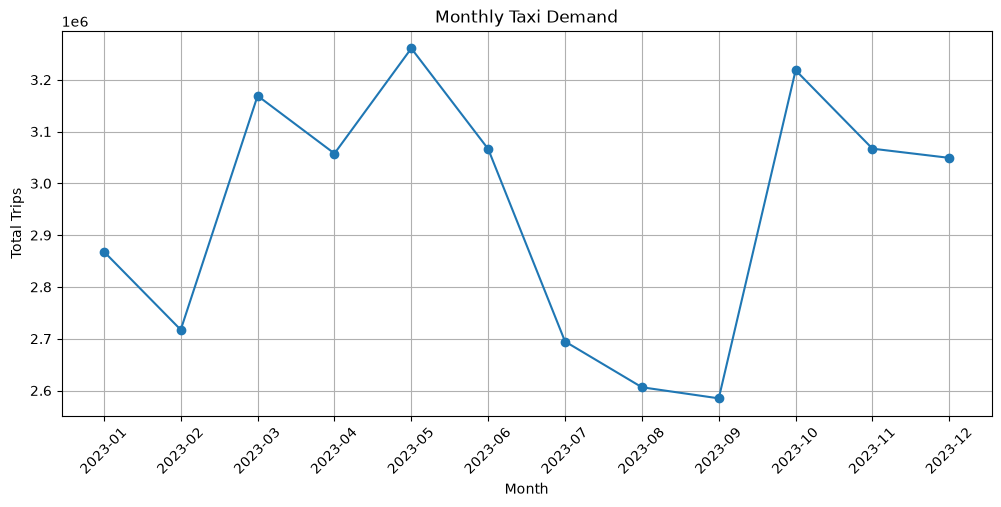

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["total_trips"], marker="o")
plt.title("Monthly Taxi Demand")
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

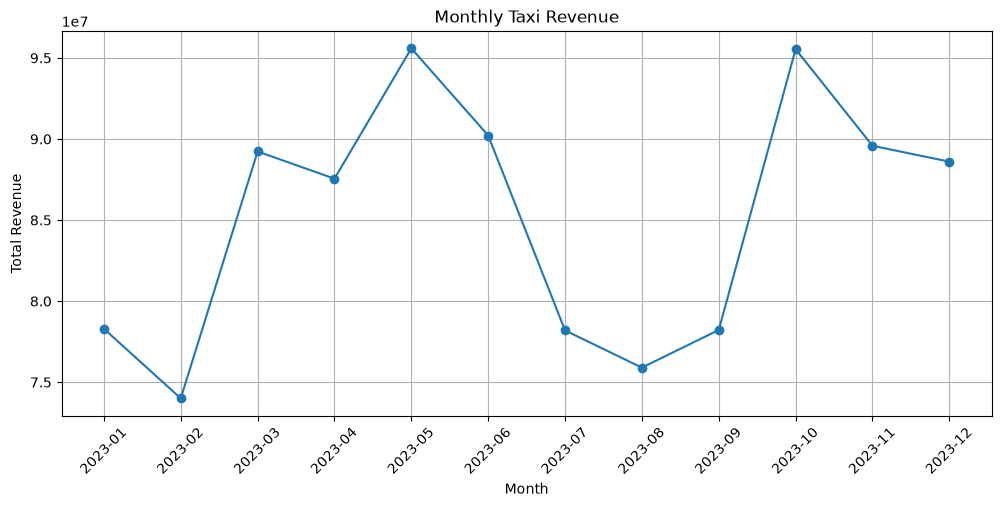

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(df_monthly["pickup_year_month"], df_monthly["total_revenue"], marker="o")
plt.title("Monthly Taxi Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

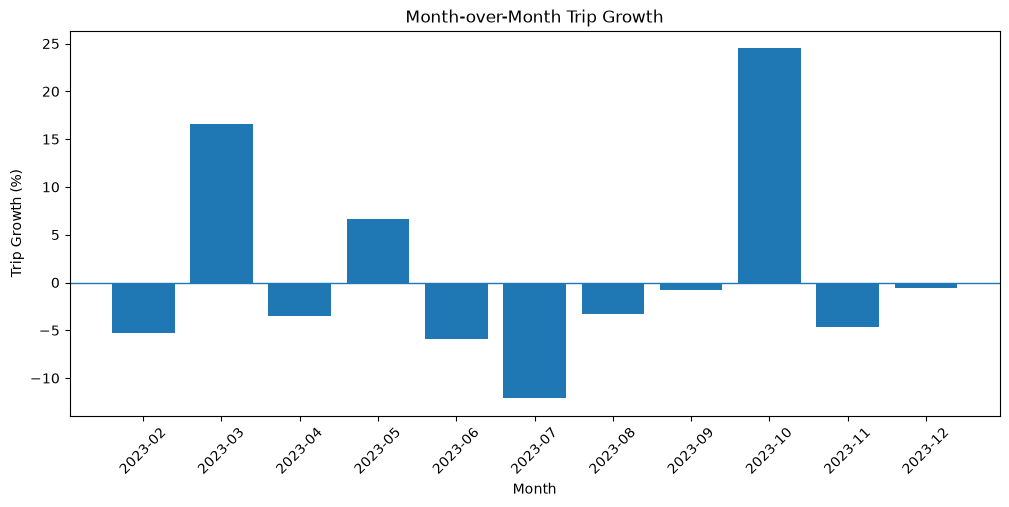

In [10]:
plt.figure(figsize=(12, 5))
plt.bar(df_monthly["pickup_year_month"], df_monthly["trips_mom_growth_percentage"])
plt.title("Month-over-Month Trip Growth")
plt.xlabel("Month")
plt.ylabel("Trip Growth (%)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.show()

In [13]:
query_peak_hour = """
SELECT
    pickup_hour,
    pickup_time_period,
    total_trips,
    total_revenue,
    avg_revenue_per_trip,
    avg_trip_distance,
    avg_trip_duration_minutes,
    demand_rank,
    revenue_rank
FROM `nyc-taxi-analytics-1.nyc_taxi_dbt_reporting.peak_hour_analysis`
ORDER BY pickup_hour
"""

df_peak_hour = run_query(query_peak_hour)
df_peak_hour.head()

,pickup_hour,pickup_time_period,total_trips,total_revenue,avg_revenue_per_trip,avg_trip_distance,avg_trip_duration_minutes,demand_rank,revenue_rank
0,0,Late night,993738,"29,104,583.22",29.29,4.00,15.92,17,17
1,1,Late night,664396,"17,739,452.95",26.70,3.56,15.17,19,19
2,2,Late night,435923,"10,986,456.87",25.20,3.37,14.02,21,21
3,3,Late night,282756,"7,461,934.98",26.39,3.55,14.34,22,22
4,4,Late night,176685,"5,936,501.38",33.60,5.01,15.62,24,24


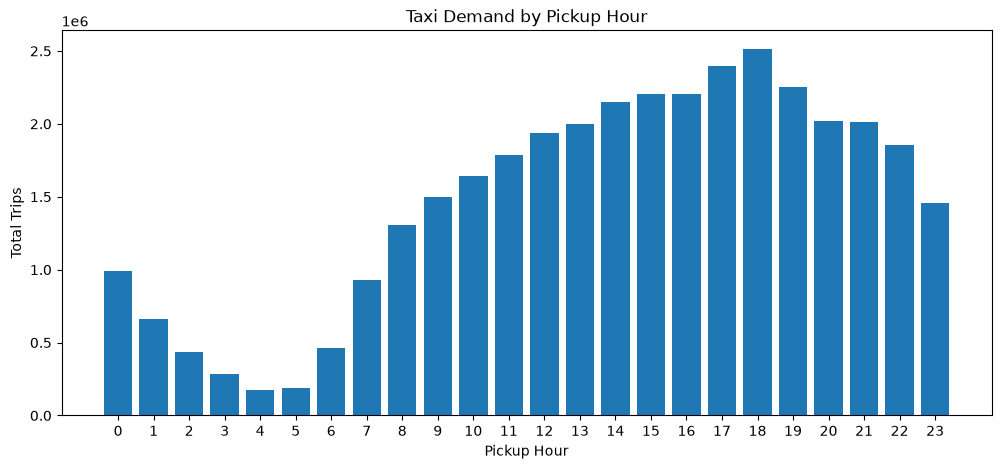

In [14]:
plt.figure(figsize=(12, 5))
plt.bar(df_peak_hour["pickup_hour"], df_peak_hour["total_trips"])
plt.title("Taxi Demand by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Trips")
plt.xticks(range(0, 24))
plt.show()

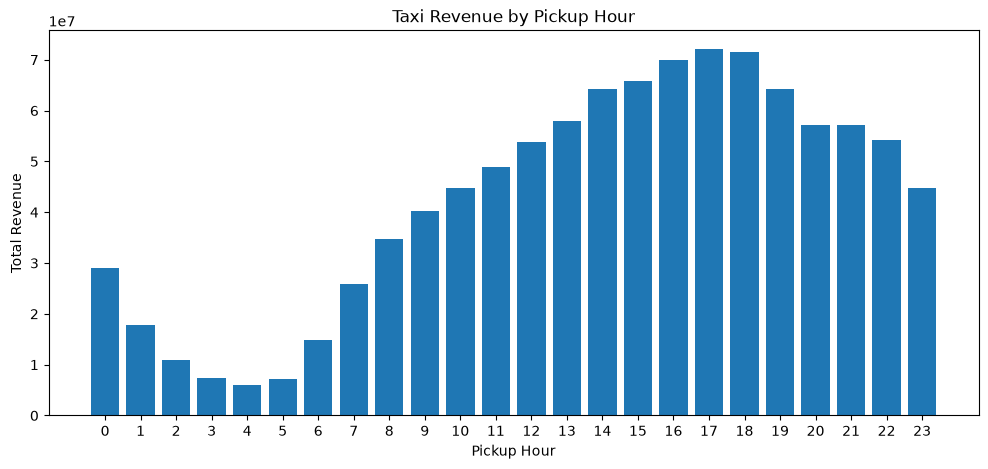

In [15]:
plt.figure(figsize=(12, 5))
plt.bar(df_peak_hour["pickup_hour"], df_peak_hour["total_revenue"])
plt.title("Taxi Revenue by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Revenue")
plt.xticks(range(0, 24))
plt.show()